In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.style as mplstyle

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

mplstyle.use(["ggplot", "fast"])

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter

In [3]:
data = processed_data_20cm

In [4]:
freqs = list(data.keys())
volts = []

for i in range(len(freqs)):
    volts.append(list(data[freqs[i]].keys()))

In [5]:
results = []  

def process_condition(data, f, v, condition, k):
    eta_r1 = data[f][v][condition]["R1"]
    eta_r2 = data[f][v][condition]["R2"]
    eta_r3 = data[f][v][condition]["R3"]

    # ----- extract series -----
    P0_r1, P0_r2, P0_r3 = eta_r1["P_0"], eta_r2["P_0"], eta_r3["P_0"]
    P1_r1, P1_r2, P1_r3 = eta_r1["P_1"], eta_r2["P_1"], eta_r3["P_1"]
    P2_r1, P2_r2, P2_r3 = eta_r1["P_2"], eta_r2["P_2"], eta_r3["P_2"]
    P3_r1, P3_r2, P3_r3 = eta_r1["P_3"], eta_r2["P_3"], eta_r3["P_3"]

    time_r1, time_r2, time_r3 = eta_r1["time"], eta_r2["time"], eta_r3["time"]

    # Masks where data is not NaN 
    mask_P0_r1 = ~P0_r1.isna()
    mask_P0_r2 = ~P0_r2.isna()
    mask_P0_r3 = ~P0_r3.isna()

    # Time arrays cut to match non-NaN data (P0)
    time_r1 = time_r1[mask_P0_r1].values
    time_r2 = time_r2[mask_P0_r2].values
    time_r3 = time_r3[mask_P0_r3].values

    # Masks for P1–P3
    mask_P1_r1 = ~P1_r1.isna()
    mask_P1_r2 = ~P1_r2.isna()
    mask_P1_r3 = ~P1_r3.isna()

    mask_P2_r1 = ~P2_r1.isna()
    mask_P2_r2 = ~P2_r2.isna()
    mask_P2_r3 = ~P2_r3.isna()

    mask_P3_r1 = ~P3_r1.isna()
    mask_P3_r2 = ~P3_r2.isna()
    mask_P3_r3 = ~P3_r3.isna()

    # Convert to numpy & sign flip
    P0_r1 = -P0_r1[mask_P0_r1].values
    P0_r2 = -P0_r2[mask_P0_r2].values
    P0_r3 = -P0_r3[mask_P0_r3].values

    P1_r1 = -P1_r1[mask_P1_r1].values
    P1_r2 = -P1_r2[mask_P1_r2].values
    P1_r3 = -P1_r3[mask_P1_r3].values

    P2_r1 = -P2_r1[mask_P2_r1].values
    P2_r2 = -P2_r2[mask_P2_r2].values
    P2_r3 = -P2_r3[mask_P2_r3].values

    P3_r1 = -P3_r1[mask_P3_r1].values
    P3_r2 = -P3_r2[mask_P3_r2].values
    P3_r3 = -P3_r3[mask_P3_r3].values

    # ---------- std-based amplitudes ----------
    def std_amp(x):
        return np.sqrt(2) * np.std(x)

    amp_P0_r1, amp_P0_r2, amp_P0_r3 = std_amp(P0_r1), std_amp(P0_r2), std_amp(P0_r3)
    amp_P1_r1, amp_P1_r2, amp_P1_r3 = std_amp(P1_r1), std_amp(P1_r2), std_amp(P1_r3)
    amp_P2_r1, amp_P2_r2, amp_P2_r3 = std_amp(P2_r1), std_amp(P2_r2), std_amp(P2_r3)
    amp_P3_r1, amp_P3_r2, amp_P3_r3 = std_amp(P3_r1), std_amp(P3_r2), std_amp(P3_r3)

    lin_amp_mean = np.array([
        np.mean([amp_P0_r1, amp_P0_r2, amp_P0_r3]),
        np.mean([amp_P1_r1, amp_P1_r2, amp_P1_r3]),
        np.mean([amp_P2_r1, amp_P2_r2, amp_P2_r3]),
        np.mean([amp_P3_r1, amp_P3_r2, amp_P3_r3]),
    ])

    # ---------- peak-based amplitudes ----------
    distance = (1 / f) * 250 * 0.8  # 80% of the period in samples

    def peak_amp(x, std):
        idx = sc.signal.find_peaks(
            x,
            height=(0.9 * np.sqrt(2) * std, 1.2 * np.sqrt(2) * std),
            distance=distance
        )[0]
        peaks = x[idx]
        peaks = peaks[peaks > 0]
        return idx, peaks, (np.mean(peaks) if len(peaks) else np.nan)

    # P0
    peak_idx_P0_r1, peaks_P0_r1, peak_amp_P0_r1 = peak_amp(P0_r1, np.std(P0_r1))
    peak_idx_P0_r2, peaks_P0_r2, peak_amp_P0_r2 = peak_amp(P0_r2, np.std(P0_r2))
    peak_idx_P0_r3, peaks_P0_r3, peak_amp_P0_r3 = peak_amp(P0_r3, np.std(P0_r3))
    # P1
    _, peaks_P1_r1, peak_amp_P1_r1 = peak_amp(P1_r1, np.std(P1_r1))
    _, peaks_P1_r2, peak_amp_P1_r2 = peak_amp(P1_r2, np.std(P1_r2))
    _, peaks_P1_r3, peak_amp_P1_r3 = peak_amp(P1_r3, np.std(P1_r3))
    # P2
    _, peaks_P2_r1, peak_amp_P2_r1 = peak_amp(P2_r1, np.std(P2_r1))
    _, peaks_P2_r2, peak_amp_P2_r2 = peak_amp(P2_r2, np.std(P2_r2))
    _, peaks_P2_r3, peak_amp_P2_r3 = peak_amp(P2_r3, np.std(P2_r3))
    # P3
    _, peaks_P3_r1, peak_amp_P3_r1 = peak_amp(P3_r1, np.std(P3_r1))
    _, peaks_P3_r2, peak_amp_P3_r2 = peak_amp(P3_r2, np.std(P3_r2))
    _, peaks_P3_r3, peak_amp_P3_r3 = peak_amp(P3_r3, np.std(P3_r3))

    scipy_amp_mean = np.array([
        np.nanmean([peak_amp_P0_r1, peak_amp_P0_r2, peak_amp_P0_r3]),
        np.nanmean([peak_amp_P1_r1, peak_amp_P1_r2, peak_amp_P1_r3]),
        np.nanmean([peak_amp_P2_r1, peak_amp_P2_r2, peak_amp_P2_r3]),
        np.nanmean([peak_amp_P3_r1, peak_amp_P3_r2, peak_amp_P3_r3]),
    ])

    # ---------- store one row per probe ----------
    probes = ["P0", "P1", "P2", "P3"]
    for i_probe, probe in enumerate(probes):
        results.append({
            "frequency": f,
            "voltage": v,
            "condition": condition,
            "probe": probe,
            "lin_amp": lin_amp_mean[i_probe],
            "scipy_amp": scipy_amp_mean[i_probe],
            "ak_scipy": scipy_amp_mean[i_probe] * k,
            "ak_lin": lin_amp_mean[i_probe] * k,
            "kH": k * 0.2,
        })

    # ---------- plotting (P0 only, fix peak index names) ----------
    fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    ax[0].plot(time_r1, P0_r1, color="C0", label=f"Mean = {np.mean(P0_r1):.3g} m")
    ax[1].plot(time_r2, P0_r2, color="C0", label=f"Mean = {np.mean(P0_r2):.3g} m")
    ax[2].plot(time_r3, P0_r3, color="C0", label=f"Mean = {np.mean(P0_r3):.3g} m")

    ax[0].hlines(amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1],
                 color="k", linestyle="--", label=f"Amplitude = {amp_P0_r1:.4f} m")
    ax[0].hlines(-amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1], color="k", linestyle="--")

    ax[1].hlines(amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1],
                 color="k", linestyle="--", label=f"Amplitude = {amp_P0_r2:.4f} m")
    ax[1].hlines(-amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1], color="k", linestyle="--")

    ax[2].hlines(amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1],
                 color="k", linestyle="--", label=f"Amplitude = {amp_P0_r3:.4f} m")
    ax[2].hlines(-amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1], color="k", linestyle="--")

    # use correct peak index variables here:
    ax[0].plot(time_r1[peak_idx_P0_r1], peaks_P0_r1, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P0_r1):.4f} m\nCount = {len(peaks_P0_r1)}")
    ax[1].plot(time_r2[peak_idx_P0_r2], peaks_P0_r2, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P0_r2):.4f} m\nCount = {len(peaks_P0_r2)}")
    ax[2].plot(time_r3[peak_idx_P0_r3], peaks_P0_r3, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P0_r3):.4f} m\nCount = {len(peaks_P0_r3)}")

    ax[0].set_title("R1")
    ax[1].set_title("R2")
    ax[2].set_title("R3")

    for a in ax:
        a.set_xlabel("Time [s]")
        a.set_ylabel(r"$\eta$ [m]")

    ax[0].legend(loc="center left")
    ax[1].legend(loc="center left")
    ax[2].legend(loc="center left")

    cond_str = "With plates" if condition == "p005" else "No plates"
    a_mean_P0 = np.mean([np.mean(peaks_P0_r1), np.mean(peaks_P0_r2), np.mean(peaks_P0_r3)])
    fig.suptitle(f"$P_0$, f = {f} Hz, A = {v} V, {cond_str}, ak = {a_mean_P0 * k:.2f}, kH = {k * 0.2:.2f}")

    plt.tight_layout()
    fr = str(f).replace(".", "")
    am = str(v).replace(".", "")
    plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_P0/f{fr}_a{am}_{condition}_P0.png", dpi=200)
    plt.close(fig)


# ---------- main loop ----------
for i, f in enumerate(freqs):
    k = estimate_wavenumber(f, 0.2)
    for v in volts[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data, f, v, condition="p005", k=k)
        process_condition(data, f, v, condition="None", k=k)

# ---------- build dataframe ----------
df_amp = pd.DataFrame(results)


Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Frequency: 1.8, Voltage: 0.1
Frequency: 1.8, Voltage: 0.2
Frequency: 1.8, Voltage: 0.25
Frequency: 1.8, Voltage: 0.3


In [6]:
results = []  

def process_condition(data, f, v, condition, k):
    eta_r1 = data[f][v][condition]["R1"]
    eta_r2 = data[f][v][condition]["R2"]
    eta_r3 = data[f][v][condition]["R3"]

    # ----- extract series -----
    P0_r1, P0_r2, P0_r3 = eta_r1["P_0"], eta_r2["P_0"], eta_r3["P_0"]
    P1_r1, P1_r2, P1_r3 = eta_r1["P_1"], eta_r2["P_1"], eta_r3["P_1"]
    P2_r1, P2_r2, P2_r3 = eta_r1["P_2"], eta_r2["P_2"], eta_r3["P_2"]
    P3_r1, P3_r2, P3_r3 = eta_r1["P_3"], eta_r2["P_3"], eta_r3["P_3"]

    time_r1, time_r2, time_r3 = eta_r1["time"], eta_r2["time"], eta_r3["time"]

    # Masks where data is not NaN 
    mask_P0_r1 = ~P0_r1.isna()
    mask_P0_r2 = ~P0_r2.isna()
    mask_P0_r3 = ~P0_r3.isna()

    # Masks for P1–P3
    mask_P1_r1 = ~P1_r1.isna()
    mask_P1_r2 = ~P1_r2.isna()
    mask_P1_r3 = ~P1_r3.isna()

    mask_P2_r1 = ~P2_r1.isna()
    mask_P2_r2 = ~P2_r2.isna()
    mask_P2_r3 = ~P2_r3.isna()

    mask_P3_r1 = ~P3_r1.isna()
    mask_P3_r2 = ~P3_r2.isna()
    mask_P3_r3 = ~P3_r3.isna()

    # Convert to numpy & sign flip
    P0_r1 = -P0_r1[mask_P0_r1].values
    P0_r2 = -P0_r2[mask_P0_r2].values
    P0_r3 = -P0_r3[mask_P0_r3].values

    P1_r1 = -P1_r1[mask_P1_r1].values
    P1_r2 = -P1_r2[mask_P1_r2].values
    P1_r3 = -P1_r3[mask_P1_r3].values

    P2_r1 = -P2_r1[mask_P2_r1].values
    P2_r2 = -P2_r2[mask_P2_r2].values
    P2_r3 = -P2_r3[mask_P2_r3].values

    P3_r1 = -P3_r1[mask_P3_r1].values
    P3_r2 = -P3_r2[mask_P3_r2].values
    P3_r3 = -P3_r3[mask_P3_r3].values

    # Time arrays cut to match non-NaN data (P3)
    time_P3_r1 = time_r1[mask_P3_r1].values
    time_P3_r2 = time_r2[mask_P3_r2].values
    time_P3_r3 = time_r3[mask_P3_r3].values

    # ---------- std-based amplitudes ----------
    def std_amp(x):
        return np.sqrt(2) * np.std(x)

    amp_P0_r1, amp_P0_r2, amp_P0_r3 = std_amp(P0_r1), std_amp(P0_r2), std_amp(P0_r3)
    amp_P1_r1, amp_P1_r2, amp_P1_r3 = std_amp(P1_r1), std_amp(P1_r2), std_amp(P1_r3)
    amp_P2_r1, amp_P2_r2, amp_P2_r3 = std_amp(P2_r1), std_amp(P2_r2), std_amp(P2_r3)
    amp_P3_r1, amp_P3_r2, amp_P3_r3 = std_amp(P3_r1), std_amp(P3_r2), std_amp(P3_r3)

    lin_amp_mean = np.array([
        np.mean([amp_P0_r1, amp_P0_r2, amp_P0_r3]),
        np.mean([amp_P1_r1, amp_P1_r2, amp_P1_r3]),
        np.mean([amp_P2_r1, amp_P2_r2, amp_P2_r3]),
        np.mean([amp_P3_r1, amp_P3_r2, amp_P3_r3]),
    ])

    # ---------- peak-based amplitudes ----------
    distance = (1 / f) * 250 * 0.8  # 80% of the period in samples

    def peak_amp(x, std):
        idx = sc.signal.find_peaks(
            x,
            height=(0.9 * np.sqrt(2) * std, 1.2 * np.sqrt(2) * std),
            distance=distance
        )[0]
        peaks = x[idx]
        peaks = peaks[peaks > 0]
        return idx, peaks, (np.mean(peaks) if len(peaks) else np.nan)

    # P0
    peak_idx_P0_r1, peaks_P0_r1, peak_amp_P0_r1 = peak_amp(P0_r1, np.std(P0_r1))
    peak_idx_P0_r2, peaks_P0_r2, peak_amp_P0_r2 = peak_amp(P0_r2, np.std(P0_r2))
    peak_idx_P0_r3, peaks_P0_r3, peak_amp_P0_r3 = peak_amp(P0_r3, np.std(P0_r3))
    # P1
    _, peaks_P1_r1, peak_amp_P1_r1 = peak_amp(P1_r1, np.std(P1_r1))
    _, peaks_P1_r2, peak_amp_P1_r2 = peak_amp(P1_r2, np.std(P1_r2))
    _, peaks_P1_r3, peak_amp_P1_r3 = peak_amp(P1_r3, np.std(P1_r3))
    # P2
    _, peaks_P2_r1, peak_amp_P2_r1 = peak_amp(P2_r1, np.std(P2_r1))
    _, peaks_P2_r2, peak_amp_P2_r2 = peak_amp(P2_r2, np.std(P2_r2))
    _, peaks_P2_r3, peak_amp_P2_r3 = peak_amp(P2_r3, np.std(P2_r3))
    # P3
    peak_idx_P3_r1, peaks_P3_r1, peak_amp_P3_r1 = peak_amp(P3_r1, np.std(P3_r1))
    peak_idx_P3_r2, peaks_P3_r2, peak_amp_P3_r2 = peak_amp(P3_r2, np.std(P3_r2))
    peak_idx_P3_r3, peaks_P3_r3, peak_amp_P3_r3 = peak_amp(P3_r3, np.std(P3_r3))

    scipy_amp_mean = np.array([
        np.nanmean([peak_amp_P0_r1, peak_amp_P0_r2, peak_amp_P0_r3]),
        np.nanmean([peak_amp_P1_r1, peak_amp_P1_r2, peak_amp_P1_r3]),
        np.nanmean([peak_amp_P2_r1, peak_amp_P2_r2, peak_amp_P2_r3]),
        np.nanmean([peak_amp_P3_r1, peak_amp_P3_r2, peak_amp_P3_r3]),
    ])

    # ---------- store one row per probe ----------
    probes = ["P0", "P1", "P2", "P3"]
    for i_probe, probe in enumerate(probes):
        results.append({
            "frequency": f,
            "voltage": v,
            "condition": condition,
            "probe": probe,
            "lin_amp": lin_amp_mean[i_probe],
            "scipy_amp": scipy_amp_mean[i_probe],
            "ak_scipy": scipy_amp_mean[i_probe] * k,
            "ak_lin": lin_amp_mean[i_probe] * k,
            "kH": k * 0.2,
        })

    # ---------- plotting (P3 only, fix peak index names) ----------
    fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    ax[0].plot(time_P3_r1, P3_r1, color="C0", label=f"Mean = {np.mean(P3_r1):.3g} m")
    ax[1].plot(time_P3_r2, P3_r2, color="C0", label=f"Mean = {np.mean(P3_r2):.3g} m")
    ax[2].plot(time_P3_r3, P3_r3, color="C0", label=f"Mean = {np.mean(P3_r3):.3g} m")

    ax[0].hlines(amp_P3_r1, xmin=time_P3_r1.min(), xmax=time_P3_r1.max(),
                 color="k", linestyle="--", label=f"Amplitude = {amp_P3_r1:.4f} m")
    ax[0].hlines(-amp_P3_r1, xmin=time_P3_r1.min(), xmax=time_P3_r1.max(), color="k", linestyle="--")

    ax[1].hlines(amp_P3_r2, xmin=time_P3_r2.min(), xmax=time_P3_r2.max(),
                 color="k", linestyle="--", label=f"Amplitude = {amp_P3_r2:.4f} m")
    ax[1].hlines(-amp_P3_r2, xmin=time_P3_r2.min(), xmax=time_P3_r2.max(), color="k", linestyle="--")

    ax[2].hlines(amp_P3_r3, xmin=time_P3_r3.min(), xmax=time_P3_r3.max(),
                 color="k", linestyle="--", label=f"Amplitude = {amp_P3_r3:.4f} m")
    ax[2].hlines(-amp_P3_r3, xmin=time_P3_r3.min(), xmax=time_P3_r3.max(), color="k", linestyle="--")

    # use correct peak index variables here:
    ax[0].plot(time_P3_r1[peak_idx_P3_r1], peaks_P3_r1, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P3_r1):.4f} m\nCount = {len(peaks_P3_r1)}")
    ax[1].plot(time_P3_r2[peak_idx_P3_r2], peaks_P3_r2, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P3_r2):.4f} m\nCount = {len(peaks_P3_r2)}")
    ax[2].plot(time_P3_r3[peak_idx_P3_r3], peaks_P3_r3, "x", color="C1",
               label=f"Mean peaks = {np.mean(peaks_P3_r3):.4f} m\nCount = {len(peaks_P3_r3)}")

    ax[0].set_title("R1")
    ax[1].set_title("R2")
    ax[2].set_title("R3")

    for a in ax:
        a.set_xlabel("Time [s]")
        a.set_ylabel(r"$\eta$ [m]")

    ax[0].legend(loc="center left")
    ax[1].legend(loc="center left")
    ax[2].legend(loc="center left")

    cond_str = "With plates" if condition == "p005" else "No plates"
    a_mean_P3 = np.mean([np.mean(peaks_P3_r1), np.mean(peaks_P3_r2), np.mean(peaks_P3_r3)])
    fig.suptitle(f"$P_3$, f = {f} Hz, A = {v} V, {cond_str}, ak = {a_mean_P3 * k:.2f}, kH = {k * 0.2:.2f}")

    plt.tight_layout()
    fr = str(f).replace(".", "")
    am = str(v).replace(".", "")
    plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_P3/f{fr}_a{am}_{condition}_P3.png", dpi=200)
    plt.close(fig)


# ---------- main loop ----------
for i, f in enumerate(freqs):
    k = estimate_wavenumber(f, 0.2)
    for v in volts[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data, f, v, condition="p005", k=k)
        process_condition(data, f, v, condition="None", k=k)

# ---------- build dataframe ----------
df_amp = pd.DataFrame(results)

Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Frequency: 1.8, Voltage: 0.1
Frequency: 1.8, Voltage: 0.2
Frequency: 1.8, Voltage: 0.25
Frequency: 1.8, Voltage: 0.3


In [7]:
diff = df_amp['lin_amp']-df_amp['scipy_amp']
mean = np.mean(diff)

print(f"Mean difference: {mean:.4f} m")
print(f"Relative mean difference: {mean / np.mean(df_amp['scipy_amp']):.2%}")

Mean difference: -0.0004 m
Relative mean difference: -2.92%


## Plotting the amplitude distribution

In [8]:
for f in freqs:
    if f in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]
    
    for v in volts:
        eta_no_r1 = data[f][v]["None"]["R1"]
        eta_no_r2 = data[f][v]["None"]["R2"]
        eta_no_r3 = data[f][v]["None"]["R3"]
        
        eta_p_r1 = data[f][v]["p005"]["R1"]
        eta_p_r2 = data[f][v]["p005"]["R2"]
        eta_p_r3 = data[f][v]["p005"]["R3"]

        P0_no_r1 = eta_no_r1["P_0"].values * (-1)
        P0_p_r1 = eta_p_r1["P_0"].values * (-1)
        P3_no_r1 = eta_no_r1["P_3"].values * (-1)
        P3_p_r1 = eta_p_r1["P_3"].values * (-1)

        P0_no_r2 = eta_no_r2["P_0"].values * (-1)
        P0_p_r2 = eta_p_r2["P_0"].values * (-1)
        P3_no_r2 = eta_no_r2["P_3"].values * (-1)
        P3_p_r2 = eta_p_r2["P_3"].values * (-1)

        P0_no_r3 = eta_no_r3["P_0"].values * (-1)
        P0_p_r3 = eta_p_r3["P_0"].values * (-1)
        P3_no_r3 = eta_no_r3["P_3"].values * (-1)
        P3_p_r3 = eta_p_r3["P_3"].values * (-1)

        # Detect peaks
        peak_idx_P0_no_r1 = find_peaks(P0_no_r1, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r1), 1.2*np.sqrt(2)*np.nanstd(P0_no_r1)), distance=90)[0]
        peak_idx_P3_no_r1 = find_peaks(P3_no_r1, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r1), 1.2*np.sqrt(2)*np.nanstd(P3_no_r1)), distance=90)[0]
        peak_idx_P0_p_r1 = find_peaks(P0_p_r1, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r1), 1.2*np.sqrt(2)*np.nanstd(P0_p_r1)), distance=90)[0]
        peak_idx_P3_p_r1 = find_peaks(P3_p_r1, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r1), 1.2*np.sqrt(2)*np.nanstd(P3_p_r1)), distance=90)[0]

        peak_idx_P0_no_r2 = find_peaks(P0_no_r2, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r2), 1.2*np.sqrt(2)*np.nanstd(P0_no_r2)), distance=90)[0]
        peak_idx_P3_no_r2 = find_peaks(P3_no_r2, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r2), 1.2*np.sqrt(2)*np.nanstd(P3_no_r2)), distance=90)[0]
        peak_idx_P0_p_r2 = find_peaks(P0_p_r2, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r2), 1.2*np.sqrt(2)*np.nanstd(P0_p_r2)), distance=90)[0]
        peak_idx_P3_p_r2 = find_peaks(P3_p_r2, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r2), 1.2*np.sqrt(2)*np.nanstd(P3_p_r2)), distance=90)[0]

        peak_idx_P0_no_r3 = find_peaks(P0_no_r3, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r3), 1.2*np.sqrt(2)*np.nanstd(P0_no_r3)), distance=90)[0]
        peak_idx_P3_no_r3 = find_peaks(P3_no_r3, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r3), 1.2*np.sqrt(2)*np.nanstd(P3_no_r3)), distance=90)[0]
        peak_idx_P0_p_r3 = find_peaks(P0_p_r3, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r3), 1.2*np.sqrt(2)*np.nanstd(P0_p_r3)), distance=90)[0]
        peak_idx_P3_p_r3 = find_peaks(P3_p_r3, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r3), 1.2*np.sqrt(2)*np.nanstd(P3_p_r3)), distance=90)[0]

        # Get amplitudes
        amp_P0_no_r1 = P0_no_r1[peak_idx_P0_no_r1]
        amp_P3_no_r1 = P3_no_r1[peak_idx_P3_no_r1]
        amp_P0_p_r1 = P0_p_r1[peak_idx_P0_p_r1]
        amp_P3_p_r1 = P3_p_r1[peak_idx_P3_p_r1]

        amp_p0_no_r2 = P0_no_r2[peak_idx_P0_no_r2]
        amp_p3_no_r2 = P3_no_r2[peak_idx_P3_no_r2]
        amp_p0_p_r2 = P0_p_r2[peak_idx_P0_p_r2]
        amp_p3_p_r2 = P3_p_r2[peak_idx_P3_p_r2]

        amp_p0_no_r3 = P0_no_r3[peak_idx_P0_no_r3]
        amp_p3_no_r3 = P3_no_r3[peak_idx_P3_no_r3]
        amp_p0_p_r3 = P0_p_r3[peak_idx_P0_p_r3]
        amp_p3_p_r3 = P3_p_r3[peak_idx_P3_p_r3]

        amp_p0_no = np.concatenate([amp_P0_no_r1, amp_p0_no_r2, amp_p0_no_r3])
        amp_p0_no = amp_p0_no[amp_p0_no > 0]
        amp_p3_no = np.concatenate([amp_P3_no_r1, amp_p3_no_r2, amp_p3_no_r3])
        amp_p3_no = amp_p3_no[amp_p3_no > 0]
        amp_p0_p = np.concatenate([amp_P0_p_r1, amp_p0_p_r2, amp_p0_p_r3])
        amp_p0_p = amp_p0_p[amp_p0_p > 0]
        amp_p3_p = np.concatenate([amp_P3_p_r1, amp_p3_p_r2, amp_p3_p_r3])
        amp_p3_p = amp_p3_p[amp_p3_p > 0]

        fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
        ax[0].hist(amp_p0_no, bins=20, density=True, alpha=0.5, color='C0', label='P0')
        ax[0].hist(amp_p3_no, bins=20, density=True, alpha=0.5, color='C1', label='P3')

        ax[0].axvline(amp_p0_no.mean(), color='C0', linestyle='--', label=rf'$\mu_{{P0}}$= {amp_p0_no.mean():.4f} m')
        ax[0].axvline(amp_p3_no.mean(), color='C1', linestyle='--', label=rf'$\mu_{{P3}}$= {amp_p3_no.mean():.4f} m')

        ax[0].set_title(f"No Plates")
        ax[0].set_ylabel("Density")
        ax[0].legend(ncol=2)

        ax[1].hist(amp_p0_p, bins=20, density=True, alpha=0.5, color='C2', label='P0')
        ax[1].hist(amp_p3_p, bins=20, density=True, alpha=0.5, color='C3', label='P3')

        ax[1].axvline(amp_p0_p.mean(), color='C2', linestyle='--', label=rf'$\mu_{{P0}}$= {amp_p0_p.mean():.4f} m')
        ax[1].axvline(amp_p3_p.mean(), color='C3', linestyle='--', label=rf'$\mu_{{P3}}$= {amp_p3_p.mean():.4f} m')

        ax[1].set_title(f"With Plates")
        ax[1].set_xlabel("Amplitude [m]")
        ax[1].set_ylabel("Density")
        ax[1].legend(ncol=2)

        fig.suptitle(f"Frequency: {f} Hz, Voltage: {v} V, D = 0.2 m")

        freq = str(f).replace(".", "")
        amp = str(v).replace(".", "")

        plt.tight_layout()
        plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_dist/amp_dist_f{freq}_a{amp}.png", dpi=200)
        plt.close(fig)

## Wilcoxon signed rank test

In [9]:
def wilcoxon_signed_rank_test_20cm(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = {}
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].dropna().values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            eta_P0 = eta_P0[0:len(p3_indices)] # match length to P_3
            eta_P3 = eta_P3[p3_indices]

            distance = (1/freq) * 250 * 0.8  # 80% of the period in samples, to allow for some variability

            # Detect peaks
            peak_idx_P0 = find_peaks(eta_P0, height=(0.9*np.sqrt(2)*np.nanstd(eta_P0), 1.2*np.sqrt(2)*np.nanstd(eta_P0)), distance=distance)[0]
            peak_idx_P3 = find_peaks(eta_P3, height=(0.9*np.sqrt(2)*np.nanstd(eta_P3), 1.2*np.sqrt(2)*np.nanstd(eta_P3)), distance=distance)[0]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]

            amp_diff = np.round(amp_P3 - amp_P0, decimals=4)
            stat, p_value = stats.wilcoxon(amp_diff, alternative="less")

            # Store results in a dataframe for later analysis
            results[(freq, v, cond, r)] = {
                'statistic': stat,
                'p_value': p_value,
                'n': n
            }      

        df = pd.DataFrame.from_dict(results, orient='index')
    return df

In [10]:
f11_wilcoxon = wilcoxon_signed_rank_test_20cm(1.1, 'p005')
f12_wilcoxon = wilcoxon_signed_rank_test_20cm(1.2, 'p005')
f13_wilcoxon = wilcoxon_signed_rank_test_20cm(1.3, 'p005')
f14_wilcoxon = wilcoxon_signed_rank_test_20cm(1.4, 'p005')
f15_wilcoxon = wilcoxon_signed_rank_test_20cm(1.5, 'p005')
f16_wilcoxon = wilcoxon_signed_rank_test_20cm(1.6, 'p005')
f17_wilcoxon = wilcoxon_signed_rank_test_20cm(1.7, 'p005')
f18_wilcoxon = wilcoxon_signed_rank_test_20cm(1.8, 'p005')

f11_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.1, "None")
f12_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.2, "None")
f13_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.3, "None")
f14_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.4, "None")
f15_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.5, "None")
f16_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.6, "None")
f17_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.7, "None")
f18_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.8, "None")

In [11]:
wilcoxon_p = pd.concat([f11_wilcoxon, f12_wilcoxon, f13_wilcoxon, f14_wilcoxon, f15_wilcoxon, f16_wilcoxon, f17_wilcoxon, f18_wilcoxon])
wilcoxon_no = pd.concat([f11_wilcoxon_no, f12_wilcoxon_no, f13_wilcoxon_no, f14_wilcoxon_no, f15_wilcoxon_no, f16_wilcoxon_no, f17_wilcoxon_no, f18_wilcoxon_no])

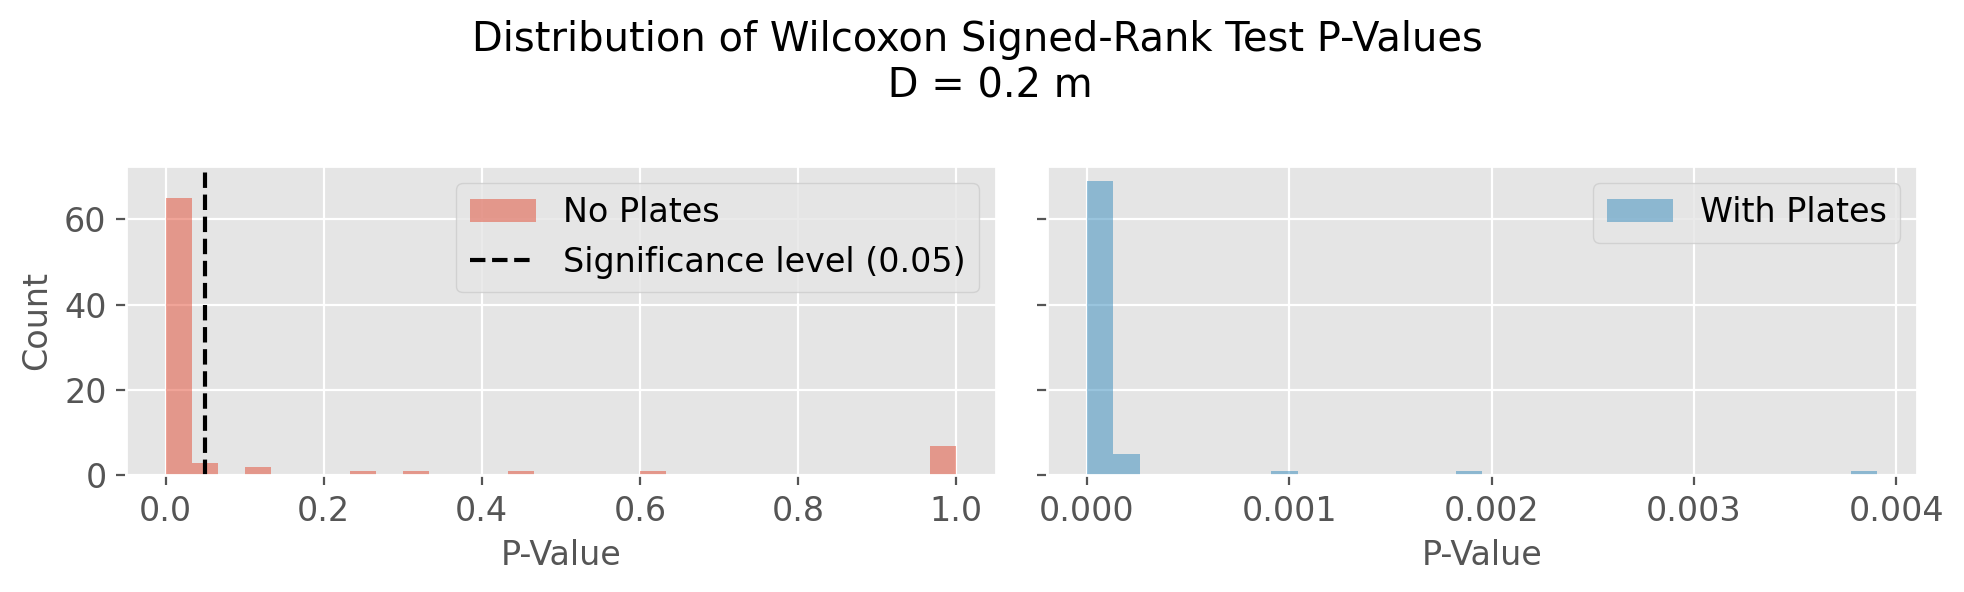

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

ax[1].hist(wilcoxon_p['p_value'], bins=30, alpha=0.5, color='C1', label='With Plates')
ax[0].hist(wilcoxon_no['p_value'], bins=30, alpha=0.5, color='C0', label='No Plates')

ax[0].axvline(0.05, color='k', linestyle='--', label='Significance level (0.05)')
#ax[1].axvline(0.05, color='k', linestyle='--', label='Significance level (0.05)')

for a in ax:
    a.set_xlabel('P-Value')
    a.legend()
ax[0].set_ylabel('Count')

fig.suptitle("Distribution of Wilcoxon Signed-Rank Test P-Values \n D = 0.2 m")
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/wilcoxon_02.png", dpi=200)

In [13]:
print("Cases with no significant difference (p > 0.05):")
print("With Plates:")
print(wilcoxon_p[wilcoxon_p['p_value'] > 0.05])
print("\nNo Plates:")
print(wilcoxon_no[wilcoxon_no['p_value'] > 0.05])

Cases with no significant difference (p > 0.05):
With Plates:
Empty DataFrame
Columns: [statistic, p_value, n]
Index: []

No Plates:
                  statistic   p_value   n
1.2 0.30 None R1      107.0  0.978327  16
              R2      123.5  0.997993  16
              R3      122.5  0.997648  16
1.4 0.30 None R1      157.0  0.059318  31
1.5 0.20 None R1      697.5  0.999959  41
              R2      698.5  0.999999  41
              R3      827.0  1.000000  41
    0.30 None R3      589.0  0.997411  41
1.6 0.30 None R2        0.0  0.125000   3
1.7 0.30 None R3       58.5  0.465992  15
1.8 0.10 None R1      664.5  0.603567  56
              R2      437.5  0.332493  56
    0.25 None R1        0.0  0.250000   2
              R2        0.0  0.125000   3
    0.30 None R1        0.0  0.062500   4
              R2        0.0  0.062500   4
